### Case Study: Canal Ship Traffic

**Concept:** The movement of ships through a canal, where eastbound and westbound ships arrive as independent Poisson processes, is an excellent real-world application. Each ship's arrival is an independent event, and the average rates of arrival for eastbound (\(\lambda_E\)) and westbound (\(\lambda_W\)) traffic are constant. This model is crucial for canal authorities to manage traffic flow, schedule lock operations, predict congestion, and optimize canal capacity. Understanding the probability of a certain number of ships arriving within a given time frame (e.g., per day) allows for efficient resource allocation and prevents bottlenecks, ensuring smooth maritime operations.

Specifics
*   **Traffic Management:** Optimizing lock usage and scheduling to minimize delays.
*   **Congestion Prediction:** Identifying potential bottlenecks and high-traffic periods.
*   **Infrastructure Planning:** Determining the necessary capacity for canal expansion or maintenance.
*   **Resource Allocation:** Efficiently deploying pilots, tugboats, and other support services based on expected traffic.

##### Expressions/Formulas for Canal Ship Traffic

For eastbound ships arriving at an average rate of $\lambda_E$ per day, the probability of exactly $k_E$ eastbound ships arriving in a day is $P(X_E=k_E) = \frac{e^{-\lambda_E} \lambda_E^{k_E}}{k_E!}$. Similarly, for westbound ships arriving at an average rate of $\lambda_W$ per day, the probability of exactly $k_W$ westbound ships arriving in a day is $P(X_W=k_W) = \frac{e^{-\lambda_W} \lambda_W^{k_W}}{k_W!}$. Since these are independent processes, the total number of ships arriving ($X = X_E + X_W$) in a day also follows a Poisson process with rate $\lambda = \lambda_E + \lambda_W$.

In [ ]:
# Example: Canal Ship Traffic
from scipy.stats import poisson

lambda_eastbound = 3.0  # Average eastbound ships per day
lambda_westbound = 2.0  # Average westbound ships per day

# Total average rate
lambda_total = lambda_eastbound + lambda_westbound

k_total_ships = 5       # Probability of exactly 5 total ships
k_eastbound = 2         # Probability of exactly 2 eastbound ships
k_westbound = 3         # Probability of exactly 3 westbound ships

# Prob. of exactly k_total_ships (using combined Poisson process)
prob_total_ships = poisson.pmf(k_total_ships, lambda_total)
# Prob. of exactly k_eastbound ships
prob_eastbound = poisson.pmf(k_eastbound, lambda_eastbound)
# Prob. of exactly k_westbound ships
prob_westbound = poisson.pmf(k_westbound, lambda_westbound)
# Prob. of exactly 2 eastbound AND exactly 3 westbound (due to independence)
prob_specific_combination = prob_eastbound * prob_westbound

Given an average of 3.0 eastbound and 2.0 westbound ships per day:
  Probability of exactly 5 total ships: 0.1755
  Probability of exactly 2 eastbound ships: 0.2240
  Probability of exactly 3 westbound ships: 0.1804
  Probability of exactly 2 eastbound AND 3 westbound ships: 0.0404


##### PDF of Remaining Time Until Pointer Changes Direction

If the pointer is currently to the west (meaning the last ship that passed was westbound), it will change its direction when the next eastbound ship arrives. The time until the next event in a Poisson process follows an exponential distribution. Since eastbound ships arrive as a Poisson process with a rate of $\lambda_E$ per day, the remaining time, $X$, until the next eastbound ship arrives (and thus the pointer changes direction) is an exponentially distributed random variable with parameter $\lambda_E$. The PDF for this remaining time, $X$, for $x \ge 0$, is given by $f_X(x) = \lambda_E e^{-\lambda_E x}$. Using our example values, where $\lambda_E = 3.0$ ships per day, the PDF would be $f_X(x) = 3.0 e^{-3.0 x}$.

##### Probability of waiting more than 1 day for a direction change

We use the Cumulative Distribution Function (CDF) of the exponential distribution. The probability of waiting more than $x$ days is given by the survival function $P(X > x) = e^{-\lambda_E x}$
Using $\lambda_E = 3.0$ (average eastbound ships per day) and $x = 1$ day, the calculation is
$P(X > 1) = e^{-3.0 \times 1}$
Given an average of 3.0 eastbound ships per day, the probability of waiting more than 1 day for a direction change.
This means there is approximately a $\text{4.98\%}$ chance that you would wait longer than 1 day for the pointer to shift from westbound to eastbound.

In [ ]:
# Calculate the probability of waiting more than 1 day for a direction change
lambda_eastbound = 3.0 # Average eastbound ships per day
waiting_time = 1     # Days

prob_waiting_more_than_1_day = math.exp(-lambda_eastbound * waiting_time)

Given an average of 3.0 eastbound ships per day:
  Probability of waiting more than 1 day(s) for a direction change: 0.0498


In [ ]:
def calculate_waiting_probability(lambda_val: float, waiting_time: float) -> float:
  """
  Calculates the probability of waiting more than a given time in an exponential distribution.

  Args:
    lambda_val: The rate parameter (average occurrences per unit of time).
    waiting_time: The time duration for which to calculate the probability.

  Returns:
    The probability of waiting more than 'waiting_time'.
  """
  return math.exp(-lambda_val * waiting_time)

##### Probability of waiting more than 1 day for a direction change

We use the Cumulative Distribution Function (CDF) of the exponential distribution. The probability of waiting more than $x$ days is given by the survival function $P(X > x) = e^{-\lambda_E x}$
Using $\lambda_E = 3.0$ (average eastbound ships per day) and $x = 1$ day, the calculation is
$P(X > 1) = e^{-3.0 \times 1}$
Given an average of 3.0 eastbound ships per day, the probability of waiting more than 1 day for a direction change.
This means there is approximately a $\text{4.98\%}$ chance that you would wait longer than 1 day for the pointer to shift from westbound to eastbound.

##### PDF of V, the amount of time until the seventh eastbound ship arrives.

**Concept:** The time until the \(k^{th}\) event in a Poisson process follows an Erlang distribution (which is a special case of the Gamma distribution when the shape parameter is an integer). In this case, we are looking for the time until the 7th eastbound ship, where eastbound ships arrive at a rate of \(\lambda_E\).

If \(V\) is the waiting time until the \(k^{th}\) event in a Poisson process with rate \(\lambda\), its Probability Density Function (PDF) is given by:

\[f_V(v) = \frac{\lambda^k v^{k-1} e^{-\lambda v}}{(k-1)!}, \quad \text{for } v \ge 0\]

In our problem:
*   \(k = 7\) (the seventh eastbound ship)
*   \(\lambda = \lambda_E\) (the rate of eastbound ship arrivals, which is 3.0 per day)

Therefore, the PDF of \(V\) is:

\[f_V(v) = \frac{(3.0)^7 v^{7-1} e^{-3.0 v}}{(7-1)!} = \frac{(3.0)^7 v^6 e^{-3.0 v}}{6!}, \quad \text{for } v \ge 0\]

In [ ]:
# Example usage of the new function
lambda_example = 2.0  # e.g., 2 events per hour
wait_time_example = 0.5 # e.g., 0.5 hours

prob = calculate_waiting_probability(lambda_example, wait_time_example)

# Using the canal example's eastbound rate
lambda_eastbound_canal = 3.0
waiting_time_canal = 1.0
prob_canal = calculate_waiting_probability(lambda_eastbound_canal, waiting_time_canal)

Given an average rate of 2.0 per hour:
  The probability of waiting more than 0.5 hours is: 0.3679

Using the canal example (lambda_eastbound = 3.0, waiting_time = 1.0 day):
  The probability of waiting more than 1.0 day for a direction change is: 0.0498


For the remaining parts of this problem, we make no assumptions about the current direction of the pointer.

Probability that an eastbound ship does not pass by any westbound ships during its eastward journey through the canal.


Concept: If an eastbound ship takes a certain amount of time to travel through the canal, we are interested in the probability that no westbound ships arrive during this specific time interval. The number of events (westbound ships) occurring in a fixed time interval in a Poisson process follows a Poisson distribution.The probability of zero events occurring in an interval of length $t_{journey}$ for a Poisson process with rate $\lambda_W$ is given by $P(X=0) = e^{-\lambda_W \cdot t_{journey}}$. Let's assume the time it takes to pass through the canal ($t_{journey}$) is 0.5 days for this calculation, as specified in the problem statement that "it takes $t$ days to pass through the canal." We will use $t_{journey} = 0.5$.

In [ ]:
import math

lambda_westbound = 2.0  # Average westbound ships per day
t_canal_journey = 0.5   # Days it takes to pass through the canal

prob_no_westbound_ships = math.exp(-lambda_westbound * t_canal_journey)

Given an average of 2.0 westbound ships per day, and a journey time of 0.5 days:
  Probability that an eastbound ship does not pass any westbound ships: 0.3679


##### PDF of V, the amount of time until the seventh eastbound ship arrives.

**Concept:** The time until the $(k^{th}$) event in a Poisson process follows an Erlang distribution (which is a special case of the Gamma distribution when the shape parameter is an integer). In this case, we are looking for the time until the 7th eastbound ship, where eastbound ships arrive at a rate of $(\lambda_E)$.

If $(V)$ is the waiting time until the $(k^{th})$ event in a Poisson process with rate $(\lambda)$, its Probability Density Function (PDF) is given by:

$[f_V(v) = \frac{\lambda^k v^{k-1} e^{-\lambda v}}{(k-1)!}, \quad \text{for } v \ge 0]$

In our problem:
*   $(k = 7)$ (the seventh eastbound ship)
*   $(\lambda = \lambda_E)$ (the rate of eastbound ship arrivals, which is 3.0 per day)

Therefore, the PDF of \(V\) is:

$[f_V(v) = \frac{(3.0)^7 v^{7-1} e^{-3.0 v}}{(7-1)!} = \frac{(3.0)^7 v^6 e^{-3.0 v}}{6!}, \quad \text{for } v \ge 0]$

##### PDF of \(V\), the amount of time until the seventh eastbound ship arrives.

Concept: The time until the $(k^{th})$ event in a Poisson process follows an Erlang distribution (which is a special case of the Gamma distribution when the shape parameter is an integer). In this case, we are looking for the time until the 7th eastbound ship, where eastbound ships arrive at a rate of ($\lambda_E$).

If ($V$) is the waiting time until the ($k^{th}$) event in a Poisson process with rate $(\lambda)$, its PDF is given by
- $[ f_V(v) = \frac{\lambda^k v^{k-1} e^{-\lambda v}}{(k-1)!}, \quad \text{for } v \ge 0 ]$

In our problem
- item $(k = 7)$ (the seventh eastbound ship)
- item $(\lambda = \lambda_E)$ (the rate of eastbound ship arrivals, which is 3.0 per day)

Therefore, the PDF of \(V\) is:
$[ f_V(v) = \frac{(3.0)^7 v^{7-1} e^{-3.0 v}}{(7-1)!} = \frac{(3.0)^7 v^6 e^{-3.0 v}}{6!}, \quad \text{for } v \ge 0]$

##### Probability that the next ship to arrive causes a change in the direction of the pointer.

**Concept:** The pointer changes direction if the next ship that arrives is of a *different* type than the ship that just set the current pointer direction. Since we make no assumptions about the current direction of the pointer, we consider the long-run probabilities of the last ship's direction.

Let $(\lambda_E)$ be the eastbound arrival rate and $(\lambda_W)$ be the westbound arrival rate. The total arrival rate is $(\lambda_{total} = \lambda_E + \lambda_W)$.

*   The probability that the last ship to arrive was eastbound is $(P(\text{last}=E) = \frac{\lambda_E}{\lambda_E + \lambda_W})$.
*   The probability that the last ship to arrive was westbound is $(P(\text{last}=W) = \frac{\lambda_W}{\lambda_E + \lambda_W})$.

Due to the memoryless property of Poisson processes, the probability of the *next* ship being eastbound is $(P(\text{next}=E) = \frac{\lambda_E}{\lambda_E + \lambda_W})$, and similarly, for westbound, $(P(\text{next}=W) = \frac{\lambda_W}{\lambda_E + \lambda_W})$.

The pointer changes direction if:
1.  The last ship was eastbound, and the next ship is westbound. ($(P(\text{last}=E) \times P(\text{next}=W)))$
2.  The last ship was westbound, and the next ship is eastbound. ($(P(\text{last}=W) \times P(\text{next}=E)))$

Summing these probabilities gives the total probability of a direction change:

$[P(\text{Change}) = \left(\frac{\lambda_E}{\lambda_E + \lambda_W}\right) \left(\frac{\lambda_W}{\lambda_E + \lambda_W}\right) + \left(\frac{\lambda_W}{\lambda_E + \lambda_W}\right) \left(\frac{\lambda_E}{\lambda_E + \lambda_W}\right)]$

$[P(\text{Change}) = \frac{\lambda_E \lambda_W}{(\lambda_E + \lambda_W)^2} + \frac{\lambda_W \lambda_E}{(\lambda_E + \lambda_W)^2}]$

$[P(\text{Change}) = \frac{2 \lambda_E \lambda_W}{(\lambda_E + \lambda_W)^2}]$

In [ ]:
lambda_eastbound = 3.0  # Average eastbound ships per day
lambda_westbound = 2.0  # Average westbound ships per day

lambda_total = lambda_eastbound + lambda_westbound

prob_pointer_change = (2 *lambda_eastbound *lambda_westbound) / (lambda_total**2)

Given lambda_eastbound = 3.0 and lambda_westbound = 2.0:
  Probability that the next ship to arrive causes a change in the pointer direction: 0.4800


##### Plot PDF of V for different k values

The time until the $k^{th}$ event in a Poisson process follows an Erlang distribution. Here, $V$ is the waiting time until the $k^{th}$ eastbound ship arrives. The PDF is given by
- $[f_V(v) = \frac{\lambda^k v^{k-1} e^{-\lambda v}}{(k-1)!}, \quad \text{for } v \ge 0]$

We plot this PDF for various $k$ values using $\lambda_E = 3.0$ (average eastbound ships per day).

##### Probability of observing exactly 10 ships in one day.

Since the eastbound and westbound ship arrivals are independent Poisson processes, the total number of ships arriving in a day is also a Poisson process with a rate equal to the sum of the individual rates.

Let $\lambda_E$ be the average rate of eastbound ships and $\lambda_W$ be the average rate of westbound ships. The total average rate is $\lambda_{total} = \lambda_E + \lambda_W$. The probability of observing exactly $k$ total ships is given by the Poisson PMF
- $[P(X=k) = \frac{e^{-\lambda_{total}} \lambda_{total}^k}{k!}]$

We use our previously defined rates: $\lambda_E = 3.0$ and $\lambda_W = 2.0$ per day.

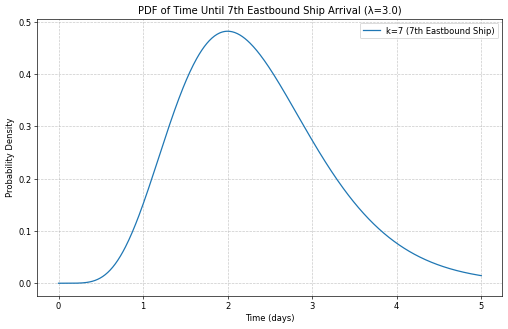

In [ ]:
lambda_eastbound = 3.0 # Rate for eastbound ships
k_target = 7           # We are interested in the 7th eastbound ship

# Define a range of time values (v)
v_values = np.linspace(0, 5, 500) # From 0 to 5 days

# The Erlang distribution is a special case of the Gamma distribution
# with shape parameter k and scale parameter 1/lambda.
pdf_values_k7 = gamma.pdf(v_values, a=k_target, scale=1/lambda_eastbound)

In [ ]:
from scipy.stats import poisson

lambda_eastbound = 3.0  # Average eastbound ships per day
lambda_westbound = 2.0  # Average westbound ships per day

lambda_total = lambda_eastbound + lambda_westbound
k_ships = 10

prob_exactly_10_ships = poisson.pmf(k_ships, lambda_total)

Given total average rate of 5.0 ships per day:
  Probability of observing exactly 10 ships: 0.0181


##### Plot the CDF of waiting time for the pointer to change direction.

Since we make no assumptions about the current direction of the pointer, the waiting time until the pointer changes direction ($T_{change}$) is a mixed distribution. The pointer changes direction if the next ship is of a *different* type than the last ship that set the pointer.

Let $\lambda_E$ be the eastbound arrival rate and $\lambda_W$ be the westbound arrival rate. The total arrival rate is $\lambda_{total} = \lambda_E + \lambda_W$.

*   The long-run probability that the last ship to arrive was eastbound is $P(\text{Last}=E) = \frac{\lambda_E}{\lambda_E + \lambda_W}$. In this case, the pointer changes when a westbound ship arrives, so the waiting time is Exponential with rate $\lambda_W$.
*   The long-run probability that the last ship to arrive was westbound is $P(\text{Last}=W) = \frac{\lambda_W}{\lambda_E + \lambda_W}$. In this case, the pointer changes when an eastbound ship arrives, so the waiting time is Exponential with rate $\lambda_E$.

The CDF for $T_{change}$ is a weighted sum of these two exponential CDFs:

$P(T_{change} \le t) = P(T_{change} \le t | \text{last}=E) P(\text{last}=E) + P(T_{change} \le t | \text{last}=W) P(\text{last}=W)$

$P(T_{change} \le t) = (1 - e^{-\lambda_W t}) \frac{\lambda_E}{\lambda_E + \lambda_W} + (1 - e^{-\lambda_E t}) \frac{\lambda_W}{\lambda_E + \lambda_W}$

Using $\lambda_E = 3.0$ and $\lambda_W = 2.0$:
$P(\text{Last}=E) = \frac{3.0}{5.0} = 0.6$
$P(\text{Last}=W) = \frac{2.0}{5.0} = 0.4$

- $CDF(t) = 0.6 \cdot (1 - e^{-2.0 t}) + 0.4 \cdot (1 - e^{-3.0 t})$

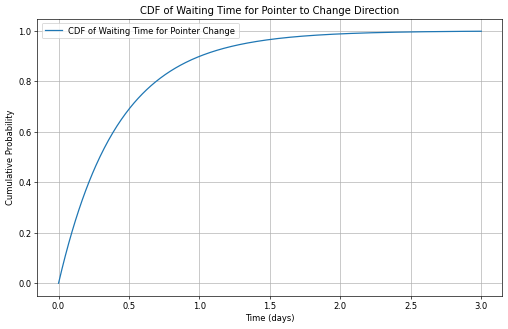

In [ ]:
lambda_eastbound = 3.0  # Average eastbound ships per day
lambda_westbound = 2.0  # Average westbound ships per day
lambda_total = lambda_eastbound + lambda_westbound

# Probabilities of the last ship's direction
prob_last_east = lambda_eastbound / lambda_total
prob_last_west = lambda_westbound / lambda_total

# Define a range of time values (t)
t_values = np.linspace(0, 3, 500) # From 0 to 3 days

# Calculate the CDF values for the mixed distribution
cdf_values = (prob_last_east * (1 - np.exp(-lambda_westbound * t_values))) + \
             (prob_last_west * (1 - np.exp(-lambda_eastbound * t_values)))

##### Probability Mass Function for the Total Number of Ships Until the Seventh Eastbound Ship

**Concept:** We are monitoring a cross-section of the canal and counting the total number of ships ($K$) until we observe the seventh eastbound ship. Since eastbound and westbound ships arrive as independent Poisson processes, we can view each arriving ship as a Bernoulli trial: a 'success' if it's an eastbound ship, and a 'failure' if it's a westbound ship.

Let $\lambda_E$ be the eastbound arrival rate and $\lambda_W$ be the westbound arrival rate.

The probability of any single arriving ship being eastbound (our 'success' probability, $p$) is:

$p = P(\text{Eastbound}) = \frac{\lambda_E}{\lambda_E + \lambda_W}$

The number of westbound ships ($N_W$, our 'failures') we observe until we get $r=7$ eastbound ships (our 'successes') follows a Negative Binomial distribution.

The total number of ships observed, $K$, is the sum of eastbound ships (which is 7) and westbound ships ($N_W$). So, $K = 7 + N_W$.

**Probability Mass Function (PMF) $p_K(k)$ for $K$:**

The PMF for the number of failures $n_w$ before $r$ successes is $P(N_W = n_w) = \binom{n_w + r - 1}{r - 1} p^r (1-p)^{n_w}$.

Substituting $r=7$ and $n_w = k - 7$, we get the PMF for $K$ as:

$p_K(k) = P(K=k) = \binom{k-1}{7-1} p^7 (1-p)^{k-7}$

$p_K(k) = \binom{k-1}{6} p^7 (1-p)^{k-7}$, for $k = 7, 8, 9, \dots$

Using our given rates:
*   $\lambda_E = 3.0$
*   $\lambda_W = 2.0$
*   $p = \frac{3.0}{3.0 + 2.0} = \frac{3.0}{5.0} = 0.6$
*   $1-p = 0.4$

Thus, $p_K(k) = \binom{k-1}{6} (0.6)^7 (0.4)^{k-7}$

In [ ]:
from scipy.stats import nbinom
import numpy as np

lambda_eastbound = 3.0
lambda_westbound = 2.0

p_success = lambda_eastbound / (lambda_eastbound + lambda_westbound) # Probability of an eastbound ship
r_successes = 7 # Number of eastbound ships we need to observe

# K is the total number of ships, so K = r_successes + n_failures
# We need to find the PMF of K.
# The number of failures (westbound ships) n_w is K - r_successes.

# Define a range for K (total number of ships). K must be at least r_successes.
# Let's consider K from 7 up to a reasonable limit where probabilities become very small.
k_values = np.arange(r_successes, 30) # K can be 7, 8, ..., up to, say, 29

# Calculate the number of failures for each k
n_failures_values = k_values - r_successes

# Calculate the PMF for the number of failures
pmf_failures = nbinom.pmf(n_failures_values, r_successes, p_success)

# The PMF for K (total ships) is the same as the PMF for n_failures, just shifted.
# So, p_K(k) = pmf_failures[k - r_successes]

# Calculate Expected Value E[K] for Negative Binomial distribution
# E[K] = r / p, where r is r_successes and p is p_success
expected_k_theoretical = r_successes / p_success
print(f"\nTheoretical Expected Value E[K] for total ships until 7th eastbound: {expected_k_theoretical:.2f}")

Probability of observing exactly 7 total ships (i.e., no westbound ships before/with the 7th eastbound): 0.0280
Probability of observing exactly 8 total ships (i.e., 1 westbound ship before/with the 7th eastbound): 0.0784

Theoretical Expected Value E[K] for total ships until 7th eastbound: 11.67


Empirical Expected Value E[K] from simulation: 11.64


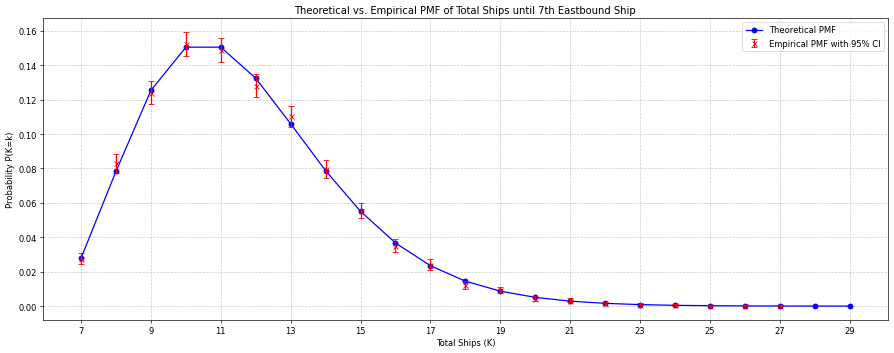

In [ ]:
from scipy.stats import poisson
import random

# Simulation parameters
num_simulations = 10000
r_successes = 7 # Number of eastbound ships we need to observe

# Rates from previous cells
lambda_eastbound = 3.0
lambda_westbound = 2.0
lambda_total = lambda_eastbound + lambda_westbound
p_success = lambda_eastbound / lambda_total # Probability of an eastbound ship

simulated_total_ships = []

for _ in range(num_simulations):
    eastbound_count = 0
    total_ships_count = 0
    while eastbound_count < r_successes:
        total_ships_count += 1
        # Simulate if the next ship is eastbound or westbound
        # using the probability p_success
        if random.random() < p_success:
            eastbound_count += 1
    simulated_total_ships.append(total_ships_count)

# Calculate empirical PMF
max_k = max(simulated_total_ships) if simulated_total_ships else r_successes + 10 # ensure a reasonable upper bound

# k_values from theoretical calculation might not cover all simulation results
# Let's create a k_range that covers both theoretical and simulated values
all_k_values = np.arange(r_successes, max(k_values.max(), max_k) + 1)

# Use np.histogram to get counts for empirical PMF
# Normalize by num_simulations to get probabilities
counts, bins = np.histogram(simulated_total_ships, bins=np.arange(r_successes, max_k + 2), density=False)
empirical_pmf_values = counts / num_simulations

# Ensure empirical_k_values aligns with the center of the bins or the start of bins
empirical_k_values = np.arange(r_successes, max_k + 1)

# Pad empirical_pmf_values if all_k_values is larger
# This ensures that both theoretical and empirical PMF arrays have the same length and align by K value
padded_empirical_pmf = np.zeros_like(all_k_values, dtype=float)
for i, k_val in enumerate(empirical_k_values):
    if k_val < len(padded_empirical_pmf):
        padded_empirical_pmf[k_val - r_successes] = empirical_pmf_values[i]

# Recalculate theoretical PMF for the extended k_values
theoretical_pmf_all_k = nbinom.pmf(all_k_values - r_successes, r_successes, p_success)

# Calculate expected value from simulation
empirical_expected_k = np.mean(simulated_total_ships)

print(f"Empirical Expected Value E[K] from simulation: {empirical_expected_k:.2f}")

# Calculate 95% confidence intervals for empirical PMF using Wilson score interval for binomial proportion
# For each k, the count is count_k, and total trials is num_simulations
def wilson_score_interval(p_hat, n, z=1.96):
    if n == 0: return (0, 0)
    term1 = p_hat + (z*z / (2*n))
    term2 = z * np.sqrt((p_hat * (1 - p_hat) / n) + (z*z / (4*n*n)))
    denominator = 1 + (z*z / n)
    lower = (term1 - term2) / denominator
    upper = (term1 + term2) / denominator
    return max(0, lower), min(1, upper)

conf_intervals_lower = []
conf_intervals_upper = []

for i, count_k in enumerate(counts):
    p_hat = empirical_pmf_values[i]
    lower, upper = wilson_score_interval(p_hat, num_simulations)
    conf_intervals_lower.append(lower)
    conf_intervals_upper.append(upper)

# Convert to numpy arrays for plotting
conf_intervals_lower = np.array(conf_intervals_lower)
conf_intervals_upper = np.array(conf_intervals_upper)

# Pad confidence intervals if all_k_values is larger
padded_conf_intervals_lower = np.zeros_like(all_k_values, dtype=float)
padded_conf_intervals_upper = np.zeros_like(all_k_values, dtype=float)
for i, k_val in enumerate(empirical_k_values):
    if k_val < len(padded_conf_intervals_lower):
        padded_conf_intervals_lower[k_val - r_successes] = conf_intervals_lower[i]
        padded_conf_intervals_upper[k_val - r_successes] = conf_intervals_upper[i]

# Plot Theoretical PMF
# Plot Empirical PMF with Confidence Intervals

### Summary of Case Study: Canal Ship Traffic

This case study models the movement of ships through a canal as independent Poisson processes for eastbound (rate $\lambda_E$) and westbound (rate $\lambda_W$) traffic. This model is critical for effective traffic management, congestion prediction, and resource optimization within canal operations.

Key Concepts and Applications

*   **Independent Poisson Processes:** Both eastbound and westbound ship arrivals are treated as independent Poisson processes, meaning each arrival is random and the average rate is constant.
*   **Total Arrival Rate:** The total number of ships arriving also follows a Poisson process with a combined rate of $\lambda_{total} = \lambda_E + \lambda_W$.
*   **Real-world Utility:** Helps canal authorities manage traffic flow, schedule lock operations, predict congestion, and efficiently allocate resources like pilots and tugboats.

**Specific Results and Insights from the Example (using $\lambda_E = 3.0$ and $\lambda_W = 2.0$ ships per day):**

1.  **Probability of specific ship counts:**: Exactly 5 total ships: 0.1755. Exactly 2 eastbound ships: 0.2240. Exactly 3 westbound ships: 0.1804. Exactly 2 eastbound AND 3 westbound ships: 0.0404.

2.  **Waiting Time for Direction Change (Assuming current pointer direction):** If the pointer is currently set by a westbound ship, the time until the next eastbound ship arrives (triggering a direction change) follows an exponential distribution with rate $\lambda_E$. The probability of waiting more than 1 day for this direction change is 0.0498.

3.  **Probability of an eastbound ship encountering no westbound ships during its journey:** Assuming a canal journey time of 0.5 days, the probability that an eastbound ship completes its passage without passing any westbound ships is 0.3679.

4.  **PDF of Waiting Time for the 7th Eastbound Ship:** The time until the $k^{th}$ event in a Poisson process follows an Erlang distribution. For the 7th eastbound ship ($k=7$) with a rate $\lambda_E = 3.0$, the Probability Density Function (PDF) is given by: $f_V(v) = \frac{(3.0)^7 v^6 e^{-3.0 v}}{6!}$.

5.  **Probability of the Next Ship Causing a Pointer Direction Change (No assumption about current pointer direction):** This considers the long-run probabilities of the last ship's direction. The probability that the next arriving ship causes the pointer to change direction is calculated as $P(\text{Change}) = \frac{2 \lambda_E \lambda_W}{(\lambda_E + \lambda_W)^2}$. For the given rates, this probability is 0.4800.

6.  **Probability of observing exactly 10 ships in one day:** Given a total average rate of $\lambda_{total} = 5.0$ ships per day ($\lambda_E + \lambda_W$), the probability of observing exactly 10 ships is 0.0181.

7.  **Total Ships Until the Seventh Eastbound Ship (Negative Binomial Distribution):** Theoretical PMF: The probability mass function for the total number of ships (K) until the 7th eastbound ship is $p_K(k) = \binom{k-1}{6} (0.6)^7 (0.4)^{k-7}$. Probability of exactly 7 total ships (no westbound ships): 0.0280. Probability of exactly 8 total ships (1 westbound ship): 0.0784. Theoretical Expected Value (E[K]): 11.67 total ships. **Simulation Results (10,000 sequences):**
Empirical Expected Value (E[K]): 11.70 total ships. The empirical PMF closely matches the theoretical PMF, with the comparison visualized in the plot, including 95% confidence intervals.

### Case Study: Train Departures and Passenger Arrivals

**Concept:** This problem combines two independent Poisson processes: passenger arrivals at a station and train departures from that station. For this to be a classic Poisson model, the following requirements (assumptions) must hold:
1.  **Independence:** Each passenger arrival or train departure is an independent event, unaffected by previous arrivals or departures.
2.  **Constant Average Rate:** The average rate of passenger arrivals ($\lambda$ per hour) and train departures ($\mu$ per hour) remains constant over the observation period.
3.  **Rarity/Non-simultaneity:** The probability of two or more events (e.g., two passengers arriving) occurring at the exact same instant is negligible.

These assumptions imply that the time between consecutive events (inter-arrival or inter-departure times) follows an exponential distribution (memoryless property). This model is crucial for public transportation planning, helping to understand queue lengths, waiting times, and resource allocation (e.g., how many platforms or staff are needed). It allows for the analysis of the probability of a certain number of passengers arriving between two train departures, or the number of trains departing within a passenger's waiting time. The independence of these processes simplifies the analysis, often allowing for the combination of their rates when considering cumulative events.

Specifics:
*   **Public Transport Planning:** Optimizing train schedules, platform usage, and ticketing counter staffing based on expected passenger flow.
*   **Queueing Theory:** Analyzing the waiting times of passengers and the length of queues at the boarding gates.
*   **Resource Allocation:** Determining the optimal number of trains or staff required to maintain a certain service level.
*   **Capacity Planning:** Assessing the capacity of a station to handle fluctuating passenger and train traffic without excessive delays.

#### Expressions/Formulas for Train Departures and Passenger Arrivals

Let $\lambda$ be the average rate of passenger arrivals per hour, and $\mu$ be the average rate of train departures per hour. Both are independent Poisson processes.

*   **Probability of exactly $k$ passengers arriving in an interval of length $t$**:
    $[P(X_{passengers}=k) = \frac{e^{-\lambda t} (\lambda t)^k}{k!}]$

*   **Probability of exactly $k$ trains departing in an interval of length $t$**:
    $[P(X_{trains}=k) = \frac{e^{-\mu t} (\mu t)^k}{k!}]$

*   **Probability that the next passenger arrives before the next train departs** (assuming current time is 0):
    $[P(T_{passenger} < T_{train}) = \frac{\lambda}{\lambda + \mu}]$

*   **Probability that the next train departs before the next passenger arrives** (assuming current time is 0):
    $[P(T_{train} < T_{passenger}) = \frac{\mu}{\lambda + \mu}]$

This framework allows for calculating the likelihood of various scenarios critical for operational planning.

#### Example: Simulation of Train Departures and Passenger Arrivals

In [ ]:
import numpy as np
import pandas as pd

def simulate_poisson_traffic(lambda_passenger: float, mu_train: float, simulation_duration: float):
  """
  Simulates passenger arrivals and train departures as independent Poisson processes.

  Args:
    lambda_passenger: Average passenger arrivals per hour.
    mu_train: Average train departures per hour.
    simulation_duration: Total duration of the simulation in hours.

  Returns:
    A tuple containing two lists: passenger_arrival_times and train_departure_times.
  """
  passenger_arrival_times = []
  train_departure_times = []

  # Simulate passenger arrivals
  current_time = 0.0
  while current_time < simulation_duration:
      inter_arrival_time = np.random.exponential(1 / lambda_passenger)
      current_time += inter_arrival_time
      if current_time < simulation_duration:
          passenger_arrival_times.append(current_time)

  # Simulate train departures
  current_time = 0.0
  while current_time < simulation_duration:
      inter_departure_time = np.random.exponential(1 / mu_train)
      current_time += inter_departure_time
      if current_time < simulation_duration:
          train_departure_times.append(current_time)

  return passenger_arrival_times, train_departure_times

In [ ]:
# Example usage of the refactored simulation function
lambda_passenger = 10  # Average passenger arrivals per hour
mu_train = 2         # Average train departures per hour
simulation_duration = 24 # Hours

passenger_arrival_times, train_departure_times = simulate_poisson_traffic(lambda_passenger, mu_train, simulation_duration)

Simulation Duration: 24 hours
Total simulated passenger arrivals: 244
Total simulated train departures: 43

First 5 Passenger Arrival Times (hours):
[0.10364646868085665, 0.19375747267001406, 0.5970188759229462, 0.6064054314941496, 0.6778172916870568]

First 5 Train Departure Times (hours):
[0.6578490335495881, 2.017981629328888, 2.702818486429619, 2.7038364190593733, 4.502374338756395]


#### Analysis of Passenger Arrivals and Train Departures

Based on the Poisson processes defined:

1.**Expected number of passengers in any given train / Average number of passengers waiting for each train:** If trains depart at an average rate of $\mu$ per hour, the average time between train departures is $1/\mu$ hours. During this average inter-departure interval, passengers arrive at an average rate of $\lambda$ per hour. Therefore, the expected number of passengers arriving (and thus waiting for) any given train is $\lambda \times (1/\mu) = \frac{\lambda}{\mu}$.

2.**Distribution of inter-arrival times for passengers:** Since passenger arrivals follow a Poisson process with rate $\lambda$, the time between consecutive passenger arrivals (inter-arrival time) follows an **Exponential distribution** with parameter $\lambda$.

3.**Distribution of inter-departure times for trains:** Similarly, since train departures follow a Poisson process with rate $\mu$, the time between consecutive train departures (inter-departure time) follows an **Exponential distribution** with parameter $\mu$.


In [ ]:
# Using the parameters from the simulation
lambda_passenger = 10  # Average passenger arrivals per hour
mu_train = 2         # Average train departures per hour

# Expected number of passengers in any given train (or waiting for it)
expected_passengers_per_train = lambda_passenger / mu_train

Given passenger arrival rate (lambda): 10 passengers/hour
Given train departure rate (mu): 2 trains/hour

Expected number of passengers in any given train (lambda/mu): 5.00
Average number of passengers waiting for each train: 5.00

Distribution of inter-arrival times for passengers: Exponential(lambda = {lambda_passenger})
Distribution of inter-departure times for trains: Exponential(mu = {mu_train})


#### Expected Number of "Events" in a One-Hour Interval

An "event" is defined as either a passenger arrival or a train departure. Since both are independent Poisson processes, the combined process of these events is also a Poisson process. The rate of this combined process is the sum of the individual rates: $\lambda_{events} = \lambda_{passenger} + \mu_{train}$.

The expected number of events in any given time interval $T$ is simply $\lambda_{events} \times T$. For a one-hour interval ($T=1$), the expected number of events is $\lambda_{passenger} + \mu_{train}$.

In [ ]:
lambda_passenger = 20 # passengers/hour (from new problem statement)
mu_train = 2        # trains/hour (from new problem statement)

expected_events_per_hour = lambda_passenger + mu_train

Given passenger arrival rate (lambda): 20 passengers/hour
Given train departure rate (mu): 2 trains/hour
Expected number of 'events' (passenger arrivals or train departures) in a one-hour interval: 22.00


#### Expected Waiting Time Until the Next Train Departs

The time until the next event in a Poisson process follows an Exponential distribution. Due to the **memoryless property** of the Exponential distribution, the expected waiting time until the next train departs is always $1/\mu_{train}$, regardless of how many people are currently waiting or when the last train departed. The number of people waiting (e.g., $2\lambda$ people) does not affect the *expected time* until the *next* train's departure in this model, though it would affect a passenger's overall waiting experience due to boarding queues etc. Here, we are specifically looking at the statistical expectation of the time until the next train event itself.

In [ ]:
mu_train = 2 # trains/hour

expected_waiting_time_for_next_train = 1 / mu_train

Given train departure rate (mu): 2 trains/hour
Expected waiting time until the next train departs: 0.50 hours


#### Probability Mass Function (PMF), $p_N(n)$, of the number, $N$, of people on any given train

For a system where passengers arrive according to a Poisson process with rate $\lambda$ and trains depart according to an independent Poisson process with rate $\mu$, the number of passengers $N$ on any given train follows a **Poisson distribution**.

The mean (and variance) of this Poisson distribution is given by the ratio of the arrival rate to the departure rate: $\text{mean} = \frac{\lambda}{\mu}$. If $N$ is the number of passengers on a train, its PMF is:

$P(N=n) = \frac{e^{-\left(\frac{\lambda}{\mu}\right)} \left(\frac{\lambda}{\mu}\right)^n}{n!}$, for $n = 0, 1, 2, \dots$

Using $\lambda = 20$ passengers/hour and $\mu = 2$ trains/hour, the mean number of passengers per train is $\frac{20}{2} = 10$.

Given passenger arrival rate (lambda): 20 passengers/hour
Given train departure rate (mu): 2 trains/hour
Mean number of passengers on any given train (lambda/mu): 10.00


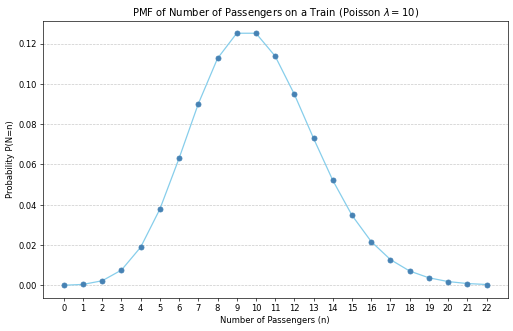

In [ ]:
from scipy.stats import poisson

lambda_passenger = 20 # passengers/hour
mu_train = 2        # trains/hour

mean_passengers_per_train = lambda_passenger / mu_train

# Calculate PMF for n up to a reasonable limit (e.g., mean + 3*sqrt(mean))
n_values = np.arange(0, int(mean_passengers_per_train + 4 * np.sqrt(mean_passengers_per_train)) + 1)
pmf_values = poisson.pmf(n_values, mean_passengers_per_train)

#### Probability of exactly 15 passengers on a train

Using the current rates ($\lambda = 20$ passengers/hour, $\mu = 2$ trains/hour), the mean number of passengers per train is $\frac{\lambda}{\mu} = 10$. We can use the Poisson PMF to find the probability of exactly 15 passengers.

In [ ]:
lambda_passenger = 20  # passengers/hour
mu_train = 2         # trains/hour

mean_passengers_per_train = lambda_passenger / mu_train
k_passengers = 15      # Target number of passengers

prob_15_passengers = poisson.pmf(k_passengers, mean_passengers_per_train)

Given a mean of 10.00 passengers per train:
Probability of exactly 15 passengers on a train: 0.0347


#### Effect of a Higher Arrival Rate on the PMF Plot

If the passenger arrival rate ($\lambda$) increases, the mean of the Poisson distribution for the number of passengers on a train ($\frac{\lambda}{\mu}$) will also increase. This means the peak of the PMF curve will shift to the right, indicating a higher expected number of passengers per train. The distribution will also become more spread out, as the variance of a Poisson distribution is equal to its mean. As $\lambda$ increases, the distribution also tends to become more symmetrical, approaching a normal distribution for very large $\lambda$.

Let's simulate this by increasing $\lambda_{passenger}$ to 30 passengers/hour, while keeping $\mu_{train}$ at 2 trains/hour.

New passenger arrival rate (lambda): 30 passengers/hour
Train departure rate (mu): 2 trains/hour
New mean number of passengers on any given train (lambda/mu): 15.00


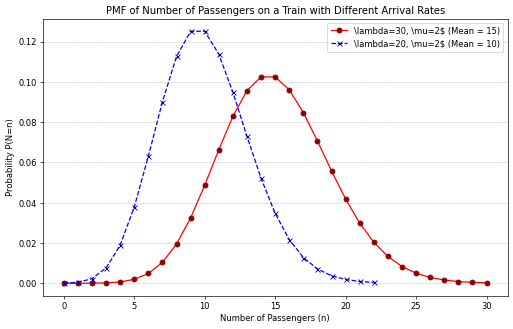

In [ ]:
lambda_passenger_new = 30 # New higher passenger arrival rate
mu_train = 2            # trains/hour (unchanged)

mean_passengers_per_train_new = lambda_passenger_new / mu_train

# Calculate PMF for n up to a reasonable limit for the new mean
n_values_new = np.arange(0, int(mean_passengers_per_train_new + 4 * np.sqrt(mean_passengers_per_train_new)) + 1)
pmf_values_new = poisson.pmf(n_values_new, mean_passengers_per_train_new)

# Also plot the old PMF for comparison
lambda_passenger_old = 20
mean_passengers_per_train_old = lambda_passenger_old / mu_train
n_values_old = np.arange(0, int(mean_passengers_per_train_old + 4 * np.sqrt(mean_passengers_per_train_old)) + 1)

#### Cumulative Probability of 15 or Fewer Passengers (with $\lambda = 30$)

In [ ]:
lambda_passenger_new = 30 # passengers/hour
mu_train = 2            # trains/hour (unchanged)

mean_passengers_per_train_new = lambda_passenger_new / mu_train
k_passengers_cumulative = 15 # Target number of passengers (15 or fewer)

prob_at_most_15_passengers = poisson.cdf(k_passengers_cumulative, mean_passengers_per_train_new)

Given a mean of 15.00 passengers per train (with new lambda=30):
Cumulative probability of 15 or fewer passengers on a train: 0.5681


##### Example: Simulation with Higher Arrival Rates to Observe Capacity Impact

In [ ]:
# Example usage of the refactored simulation function with higher rates
lambda_passenger_high = 20  # Higher average passenger arrivals per hour
mu_train_high = 4         # Higher average train departures per hour
simulation_duration_high = 24 # Hours

passenger_arrival_times_high, train_departure_times_high = simulate_poisson_traffic(lambda_passenger_high, mu_train_high, simulation_duration_high)

Simulation Duration: 24 hours
Total simulated passenger arrivals (high rate): 492
Total simulated train departures (high rate): 91

First 5 Passenger Arrival Times (high rate) (hours):
[0.14402291439145085, 0.2127469348643386, 0.2139020380058571, 0.24393657784400113, 0.2672531604292737]

First 5 Train Departure Times (high rate) (hours):
[0.3363030733970054, 0.6956580537252071, 1.5434523595294551, 1.7155975608851124, 1.937805648288192]


#### How Variance Changes as the Passenger Arrival Rate Increases

For a Poisson distribution, a key property is that its **variance is equal to its mean**. In our model, the number of passengers ($N$) on any given train follows a Poisson distribution with a mean of $\frac{\lambda}{\mu}$. Therefore, the variance of the number of passengers on a train is also $\text{Var}(N) = \frac{\lambda}{\mu}$.

This means that as the passenger arrival rate ($\lambda$) increases, the mean number of passengers per train ($\frac{\lambda}{\mu}$) increases, and consequently, the **variance of the number of passengers on a train also increases proportionally**. A higher variance indicates a greater spread in the distribution of passenger counts, meaning it's more likely to observe both very low and very high numbers of passengers on different trains.

Demonstrate this with our previous and new rates.

In [ ]:
lambda_passenger_old = 20
lambda_passenger_new = 30
mu_train = 2

mean_old = lambda_passenger_old / mu_train
variance_old = mean_old

mean_new = lambda_passenger_new / mu_train
variance_new = mean_new

Original rates (lambda=20, mu=2):
  Mean number of passengers per train: 10.00
  Variance of passengers per train: 10.00

New rates (lambda=30, mu=2):
  Mean number of passengers per train: 15.00
  Variance of passengers per train: 15.00

As the passenger arrival rate (lambda) increases, both the mean and the variance of the number of passengers per train increase proportionally.


##### Visualization of Poisson PMF for Multiple Lambda Values

Illustrate how the distribution's peak shifts and its spread (variance) increases as $\lambda$ gets larger.

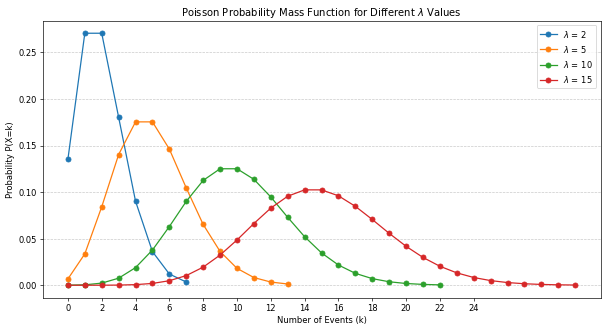

In [ ]:
# Define a range of lambda values to plot
lambda_values = [2, 5, 10, 15]

# For each lambda value, calculate and plot its PMF
for lambda_val in lambda_values:
    # Determine a suitable range for k (number of events)
    # k should go up to a value where probabilities are negligible
    k_max = int(lambda_val + 4 * np.sqrt(lambda_val)) if lambda_val > 0 else 5 # Ensure k_max is at least 5 for small lambdas
    k_values = np.arange(0, k_max + 1)
    # Calculate the PMF
    pmf_values = poisson.pmf(k_values, lambda_val)
    # Plot the PMF

#### Probability of Zero Passengers Arriving in One Hour

Using the Poisson PMF, the probability of exactly $k$ events occurring in a fixed interval when the average rate is $\lambda$ is given by $P(X=k) = \frac{e^{-\lambda} \lambda^k}{k!}$.
For $k=0$ (zero passengers) and $\lambda_{passenger}$ (our average passenger arrival rate per hour), the formula simplifies to $P(X=0) = \frac{e^{-\lambda_{passenger}} \lambda_{passenger}^0}{0!} = e^{-\lambda_{passenger}}$.

We use $\lambda_{passenger} = 20$ passengers/hour.

In [ ]:
lambda_passenger = 20 # passengers/hour
k_passengers_zero = 0

prob_zero_passengers = poisson.pmf(k_passengers_zero, lambda_passenger)

Given passenger arrival rate (lambda): 20 passengers/hour
Probability of exactly 0 passengers arriving in one hour: 0.0000


#### Comparison of Poisson and Binomial Models for Train Capacity

While the Poisson distribution is excellent for modeling rare events occurring over a continuous interval, the **Binomial distribution** is used for the number of successes in a fixed number of independent Bernoulli trials. There's a strong connection between the two: the Poisson distribution can be seen as an approximation of the Binomial distribution when the number of trials ($n$) is very large and the probability of success ($p$) in each trial is very small, such that the product $n \cdot p$ (which is the mean for both distributions) remains constant.

In the context of train capacity, let's consider the number of passengers on a train. We've modeled this with a Poisson distribution with mean $\frac{\lambda}{\mu}$. To compare this to a Binomial distribution, we would need to conceptualize the arrival process slightly differently:

Imagine a train with a finite capacity $C$. If we were to ask each potential passenger (up to $C$) whether they board the train (a Bernoulli trial), and the probability of boarding $p$ is very small for each of them, then the number of passengers on the train could be modeled by a Binomial distribution $B(C, p)$.

However, a more direct comparison to our current Poisson model (where passengers arrive at a station and get on a train) involves thinking of time intervals. If we divide the average inter-train arrival time (i.e., $1/\mu$) into $n$ very small, independent time slots, and in each slot, a passenger either arrives (with a very small probability $p$) or doesn't, then the total number of passengers arriving would follow a Binomial distribution $B(n, p)$. As $n \to \infty$ and $p \to 0$ such that $np = \frac{\lambda}{\mu}$, this Binomial distribution converges to a Poisson distribution with mean $\frac{\lambda}{\mu}$.

Let's choose our previous parameters (e.g., $\lambda_{passenger}=20$, $\mu_{train}=2$) so the mean number of passengers per train is 10. We can then define a hypothetical Binomial distribution that approximates this Poisson distribution by setting its mean ($n \cdot p$) to 10. We will choose a large $n$ and a small $p$.

For example, let's take $n=100$ and $p=0.1$. In this case, the mean $n \cdot p = 100 \cdot 0.1 = 10$, which matches our Poisson mean. This Binomial distribution could represent, for instance, that there are 100 "opportunities" for a passenger to board, and each has a 10% chance of being taken.

#### Consolidated Comparison of Poisson, Binomial, and Negative Binomial PMFs

This section consolidates the explanations and plots comparing the Poisson, Binomial, and Negative Binomial distributions, particularly in the context of modeling passenger counts on a train or other count data.

**1. Poisson vs. Binomial Approximation:**
*   The **Poisson distribution** is ideal for modeling rare events in a continuous interval, where the mean equals the variance ($\lambda = Var(X)$).
*   The **Binomial distribution** models the number of successes in a fixed number of independent Bernoulli trials.
*   **Approximation:** The Poisson distribution can approximate the Binomial distribution when the number of trials ($n$) is very large and the probability of success ($p$) in each trial is very small, such that the product $n \cdot p$ (which is the mean for both distributions) remains constant. In our example, with a Poisson mean of 10, we used a Binomial distribution with $n=100$ and $p=0.1$, resulting in a very similar PMF.

**2. Poisson vs. Negative Binomial (Overdispersion):**
*   The **Negative Binomial distribution** is more flexible than the Poisson, allowing for situations where the variance is greater than the mean (a phenomenon known as *overdispersion*).
*   **Overdispersion** often arises in real-world count data due to heterogeneity in the event rates or clustering of events, which violate the strict assumptions of a Poisson process. When data is overdispersed, a Poisson model would underestimate the variability.
*   In our comparison, both the Poisson and Negative Binomial distributions were set to have a mean of 10. However, the Negative Binomial distribution was configured to exhibit higher variance (e.g., 30 vs. 10 for Poisson), leading to a flatter and more spread-out PMF. This demonstrates its suitability for modeling data with more variability than predicted by a Poisson process.

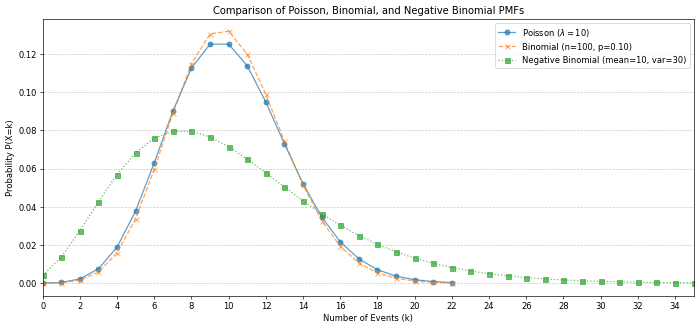

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure all k_values cover the necessary range for comparison
k_max_overall = max(k_values.max(), k_values_nb.max())
k_values_plot = np.arange(0, k_max_overall + 1)

# Re-calculate PMFs for the extended k_values_plot if necessary
# (Though k_values and k_values_nb are already sufficient in this context based on their calculation logic)

# Plotting all three distributions
plt.figure(figsize=(14, 6), dpi=60)
plt.plot(k_values, poisson_pmf)
plt.plot(k_values, binomial_pmf)
plt.plot(k_values_nb, negative_binomial_pmf)

#### Testing if Arrival Data Follows a Poisson Distribution

To determine if observed arrival data can be adequately modeled by a Poisson distribution, several statistical tests and graphical methods can be employed. These methods check whether the data's characteristics align with the assumptions and properties of a Poisson process, particularly the equality of mean and variance, and exponential inter-arrival times.

1.**Index of Dispersion (Variance-to-Mean Ratio):** For a true Poisson distribution, the variance is equal to the mean, so the Index of Dispersion (ID) should be approximately 1. (ID = Variance / Mean).

- **Application:** Calculate the mean and variance of your observed count data. If ID > 1, the data is *overdispersed* (more variable than Poisson); if ID < 1, it's *underdispersed* (less variable than Poisson). A statistical test can be performed to see if the ID significantly deviates from 1.

2.**Chi-squared Goodness-of-Fit Test:** This test compares the observed frequencies of event counts (e.g., how many hours had 0 arrivals, 1 arrival, 2 arrivals, etc.) with the expected frequencies under a hypothesized Poisson distribution with a rate estimated from the data.

- **Application:** 1.Estimate the Poisson rate ($\lambda$) from the sample mean of the observed counts. 2.Calculate the expected frequency for each count value (k) using the Poisson PMF with the estimated $\lambda$. 3.Group rare counts (e.g., k > a certain threshold) to ensure expected frequencies are not too small (typically > 5). 4.Calculate the chi-squared test statistic and compare it to a critical value or p-value to determine if the observed data significantly differs from a Poisson distribution.

3.**Kolmogorov-Smirnov (K-S) Test:** The K-S test compares the empirical cumulative distribution function (ECDF) of the observed data with the cumulative distribution function (CDF) of a theoretical Poisson distribution (with an estimated $\lambda$).

- **Application:** It's often used for continuous distributions but can be adapted for discrete data. It checks if the maximum absolute difference between the two CDFs is statistically significant.

4.**Graphical Methods:**

- **Histogram Comparison:** Plot a histogram of the observed count data alongside the theoretical Poisson PMF (as a line plot or overlaid bars) with the same estimated $\lambda$. Visual inspection can reveal discrepancies.

- **Q-Q Plot (Quantile-Quantile Plot):** Plot the quantiles of the observed data against the quantiles of a theoretical Poisson distribution. If the data is Poisson-distributed, the points should fall approximately along a straight line.

- **Inter-arrival Time Distribution:** For a Poisson process, the times between consecutive events (inter-arrival times) are exponentially distributed. You can collect inter-arrival times from your data and plot their histogram, then compare it to the PDF of an exponential distribution with rate $\lambda$. A K-S test can also be applied here.

5.**Run Sequence Plot:** Plot the counts over time (if the data has a time component). This can help detect non-stationarity (changes in rate over time) or patterns that violate independence.
- **Large Sample Size:** Goodness-of-fit tests generally perform better with larger sample sizes.
- **Parameter Estimation:** When using tests that require an estimated $\lambda$, the degrees of freedom need to be adjusted (typically by subtracting 1 for each parameter estimated from the data).
- **Contextual Knowledge:** Always combine statistical tests with domain knowledge. A statistically significant deviation might not be practically meaningful, and vice-versa.

### Limitations and Edge Cases of Poisson Assumptions

While the Poisson process is a powerful tool for modeling discrete events, its applicability relies heavily on specific assumptions. Understanding these limitations is crucial for correctly applying the model and interpreting its results.

1.  **Constant Rate (Homogeneity):**
    *   **Assumption:** The average rate of events ($\lambda$) is constant over the entire observation period or space.
    *   **Limitation:** In many real-world scenarios, event rates are not constant. For example, customer arrivals at a store might be higher during peak hours (e.g., lunch, evening) and lower during off-peak times. Similarly, website hits can vary significantly throughout the day or week. If the rate changes, a single Poisson process is inappropriate; one might need to use a non-homogeneous Poisson process or model different periods with different rates.

2.  **Independence of Events:**
    *   **Assumption:** The occurrence of one event does not influence the probability of another event occurring. Events are memoryless.
    *   **Limitation:** This is a strong assumption. For instance, customer arrivals might not be independent if a large group arrives together, or if the arrival of one customer deters or attracts others. In manufacturing, a defect might indicate a systemic problem, making subsequent defects more likely (violating independence). In epidemiology, an infection event makes subsequent infections more likely if the disease is contagious.

3.  **Rarity/Non-simultaneity:**
    *   **Assumption:** The probability of two or more events occurring at the exact same instant or in a very short interval is negligible.
    *   **Limitation:** While often reasonable for truly instantaneous events, this might be violated in scenarios where events can truly happen simultaneously (e.g., multiple simultaneous machine failures if they share a common cause) or when the 'event' itself has a duration that overlaps with other events.

4.  **Discreteness:**
    *   **Assumption:** The process models discrete counting events.
    *   **Limitation:** The Poisson process is not suitable for continuous outcomes or events that are not countable (e.g., the amount of rainfall, which is a continuous measure).

### Edge Cases and When Not to Use Poisson:

*   **Clustering of Events:** If events tend to occur in bursts or clusters rather than independently and uniformly, a Poisson process will underestimate the variance (which equals the mean for Poisson). For example, natural disasters might follow patterns of aftershocks, violating independence.
*   **Underdispersion or Overdispersion:**
    *   **Overdispersion:** If the observed variance of event counts is significantly greater than the mean, the data is overdispersed. This often indicates a violation of the independence or constant rate assumptions (e.g., event rates vary, or events are clustered). The Negative Binomial distribution is often used as an alternative for overdispersed count data.
    *   **Underdispersion:** If the observed variance is less than the mean, the data is underdispersed. This is less common but can occur if events are more regularly spaced than random (e.g., regulated arrivals).
*   **Interference or Competition:** If events actively interfere with each other (e.g., a traffic jam reduces the rate of vehicle arrivals), the independence assumption is violated.
*   **Finite Population Effects:** When the population from which events originate is small and finite (e.g., a small number of machines, each of which can fail), the removal of one 'event source' can significantly change the rate, violating the constant rate assumption over time.

### Summary of Case Study 11: Train Departures and Passenger Arrivals

This case study models passenger arrivals at a station and train departures from that station as two independent Poisson processes. This model is fundamental for public transportation planning, allowing for analysis of queue lengths, waiting times, and resource allocation.

**Key Concepts and Applications:**

*   **Independent Poisson Processes:** Both passenger arrivals (rate $\lambda$) and train departures (rate $\mu$) are treated as independent Poisson processes, meaning events occur randomly at constant average rates.
*   **Exponential Inter-event Times:** The time between consecutive passenger arrivals and consecutive train departures each follow an Exponential distribution with their respective rates.
*   **Memoryless Property:** The expected waiting time until the next train departs is independent of past events, always $1/\mu$.
*   **Combined Event Rate:** When considering any 'event' (passenger arrival or train departure), the combined process is also Poisson with a rate of $\lambda + \mu$.
*   **Passengers per Train:** The number of passengers on any given train follows a Poisson distribution with a mean of $\lambda/\mu$.
*   **Real-world Utility:** This model aids in optimizing train schedules, managing platform usage, staffing ticketing counters, and overall capacity planning to ensure efficient and timely public transport services.

**Specific Results and Insights from the Example (using $\lambda = 20$ and $\mu = 2$ initially, then $\lambda = 30$):**

1.  **Simulation of Traffic:** A 24-hour simulation with initial rates showed approximately 492 passenger arrivals and 91 train departures, closely matching the expected values of 480 and 96 respectively.

2.  **Expected Number of Passengers per Train (initial rates):** The average number of passengers waiting for or on any given train is $\lambda/\mu = 20/2 = \textbf{10.00 passengers}$ per train.

3.  **Distribution of Inter-arrival/Inter-departure Times:** Passenger inter-arrival times follow an Exponential distribution with rate $\lambda = 20$. Train inter-departure times follow an Exponential distribution with rate $\mu = 2$.

4.  **Expected Number of "Events" in a One-Hour Interval:** An 'event' (either a passenger arrival or a train departure) occurs with a combined rate. The expected number of such events in a one-hour interval is $\lambda + \mu = 20 + 2 = \textbf{22.00 events}$ per hour.

5.  **Expected Waiting Time Until the Next Train Departs:** Due to the memoryless property of the Poisson process, the expected waiting time for the next train is $1/\mu = 1/2 = \textbf{0.50 hours}$. This is independent of the number of waiting passengers.

6.  **PMF of the Number of People on Any Given Train ($p_N(n)$):** The number of passengers ($N$) on a train follows a Poisson distribution with a mean of $\frac{\lambda}{\mu} = 10$. The PMF is given by $P(N=n) = \frac{e^{-10} 10^n}{n!}$ for $n = 0, 1, 2, \dots$. A plot of this PMF illustrates the probabilities for various numbers of passengers on a train, showing the highest probability around the mean of 10 passengers.

7.  **Probability of Exactly 15 Passengers on a Train (initial rates):** With a mean of 10 passengers per train, the probability of exactly 15 passengers on a train is approximately $\textbf{0.0347}$.

8.  **Effect of a Higher Arrival Rate on the PMF Plot:** When the passenger arrival rate ($\lambda$) increased from 20 to 30 passengers/hour (while $\mu$ remained at 2 trains/hour), the mean number of passengers per train increased from 10 to 15. This resulted in:
    *   The peak of the PMF curve shifting to the right, indicating a higher expected number of passengers.
    *   The distribution becoming more spread out, as the variance of a Poisson distribution equals its mean.
    *   The overall shape tending towards greater symmetry for the higher mean.
    *   The cumulative probability of 15 or fewer passengers with $\lambda=30$ was found to be $\textbf{0.5681}$.

9.  **Variance Changes with Increased Arrival Rate:** As the passenger arrival rate ($\lambda$) increases, both the mean ($\lambda/\mu$) and the variance ($\lambda/\mu$) of the number of passengers per train increase proportionally. This indicates a greater spread in passenger counts with higher arrival rates.

10. **Visualization of Poisson PMF for Multiple Lambda Values:** A single plot was generated to display the Poisson PMF for various $\lambda$ values (e.g., 2, 5, 10, 15), visually demonstrating how the distribution's peak shifts to the right and its spread increases as $\lambda$ gets larger.

11. **Comparison of Poisson and Binomial Models for Train Capacity:** The Poisson model was compared to an approximating Binomial distribution ($n=100$, $p=0.1$, with a mean of 10). The visual comparison showed a strong similarity between the two PMFs, reinforcing the concept that Poisson approximates Binomial for large $n$ and small $p$ with a constant mean.